# Stimulus Category Decoding — Group Results

LinearSVC leave-one-run-out CV, 4 categories (face / figure / hand / house), chance = 25%.  
Two ROIs: whole-brain and visual cortex (Harvard-Oxford atlas).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

DATA_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/decoding")
LABELS = ['face', 'figure', 'hand', 'house']
CHANCE = 1 / len(LABELS)

In [8]:
records = []
cm_wb, cm_vc = [], []

for sub_dir in sorted(DATA_DIR.glob("sub-*")):
    sub_id = sub_dir.name.replace("sub-", "")
    acc_file = sub_dir / f"sub-{sub_id}_decoding_accuracy.csv"
    if not acc_file.exists():
        continue
    acc = pd.read_csv(acc_file).set_index("mask")["accuracy"]
    records.append({"subject": sub_id, "wholebrain": acc["wholebrain"], "visualcortex": acc["visualcortex"]})

    for mask, store in [("wholebrain", cm_wb), ("visualcortex", cm_vc)]:
        cm_file = sub_dir / f"sub-{sub_id}_decoding_confusion_{mask}.npy"
        if cm_file.exists():
            store.append(np.load(cm_file))

df = pd.DataFrame(records)
cm_wb = np.stack(cm_wb)
cm_vc = np.stack(cm_vc)

print(f"{len(df)} subjects loaded")

58 subjects loaded


## Group accuracy

wholebrain: mean=0.275, t(57)=6.86, p=5.40e-09  ***
visualcortex: mean=0.392, t(57)=12.96, p=1.23e-18  ***


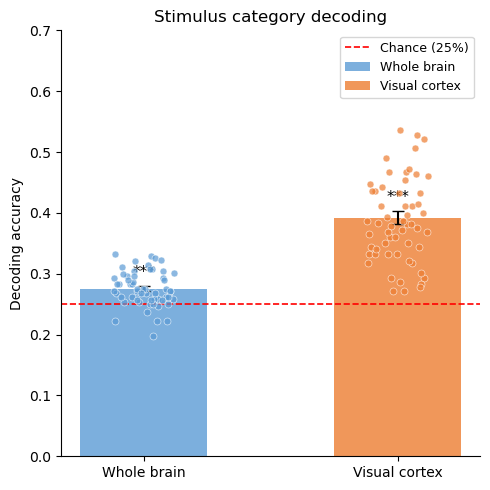

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))

masks = ["wholebrain", "visualcortex"]
labels = ["Whole brain", "Visual cortex"]
colors = ["#5B9BD5", "#ED7D31"]
x = np.arange(len(masks))
w = 0.5

for i, (mask, label, color) in enumerate(zip(masks, labels, colors)):
    vals = df[mask].values
    ax.bar(i, vals.mean(), width=w, color=color, alpha=0.8, label=label, zorder=2)
    ax.errorbar(i, vals.mean(), yerr=vals.std() / np.sqrt(len(vals)),
                fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)
    jitter = np.random.default_rng(0).uniform(-0.12, 0.12, len(vals))
    ax.scatter(i + jitter, vals, color=color, edgecolors='white',
               linewidth=0.5, s=25, alpha=0.7, zorder=4)

ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Decoding accuracy")
ax.set_ylim(0, 0.7)
ax.set_title("Stimulus category decoding")
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

for i, mask in enumerate(masks):
    vals = df[mask].values
    t, p = stats.ttest_1samp(vals, CHANCE)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    ax.text(i, vals.mean() + vals.std()/np.sqrt(len(vals)) + 0.015,
            sig, ha='center', fontsize=11)
    print(f"{mask}: mean={vals.mean():.3f}, t({len(vals)-1})={t:.2f}, p={p:.2e}  {sig}")

plt.tight_layout()
plt.show()

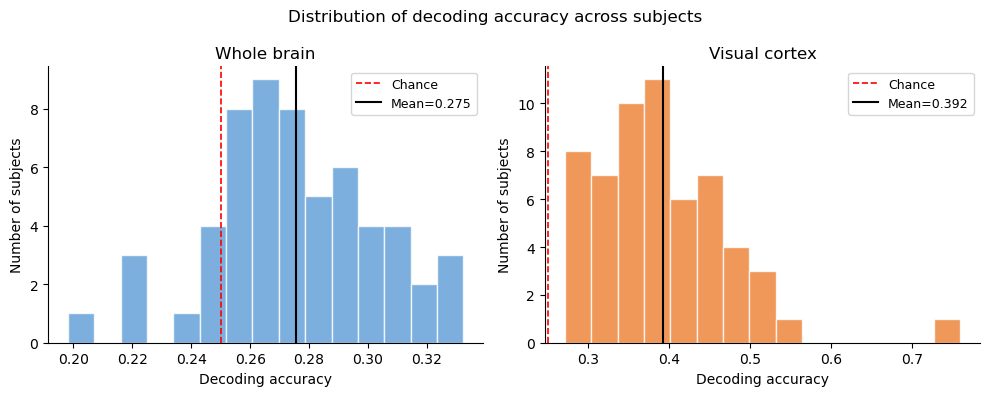

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, mask, label, color in zip(axes,
                                   ["wholebrain", "visualcortex"],
                                   ["Whole brain", "Visual cortex"],
                                   ["#5B9BD5", "#ED7D31"]):
    vals = df[mask].values
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(CHANCE, color='red', linestyle='--', linewidth=1.2, label='Chance')
    ax.axvline(vals.mean(), color='black', linestyle='-', linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_xlabel("Decoding accuracy")
    ax.set_ylabel("Number of subjects")
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle("Distribution of decoding accuracy across subjects")
plt.tight_layout()
plt.show()

## Confusion matrices (group average, normalized by true class)

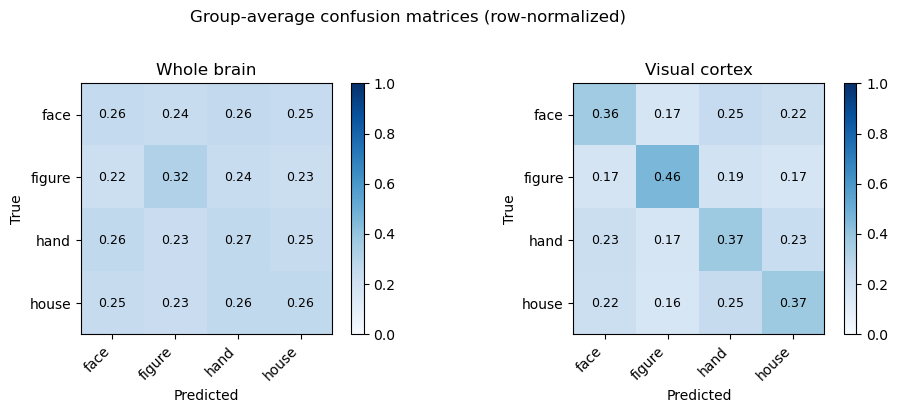

In [5]:
def normalize_cm(cm_stack):
    """Row-normalize each subject's CM, then average."""
    normed = cm_stack.astype(float)
    normed = normed / normed.sum(axis=2, keepdims=True)
    return normed.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm_stack, title in zip(axes,
                                [cm_wb, cm_vc],
                                ["Whole brain", "Visual cortex"]):
    cm_norm = normalize_cm(cm_stack)
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(LABELS, rotation=45, ha='right')
    ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for r in range(4):
        for c in range(4):
            ax.text(c, r, f"{cm_norm[r, c]:.2f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_norm[r, c] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Group-average confusion matrices (row-normalized)", y=1.02)
plt.tight_layout()
plt.show()

## Individual subject accuracy

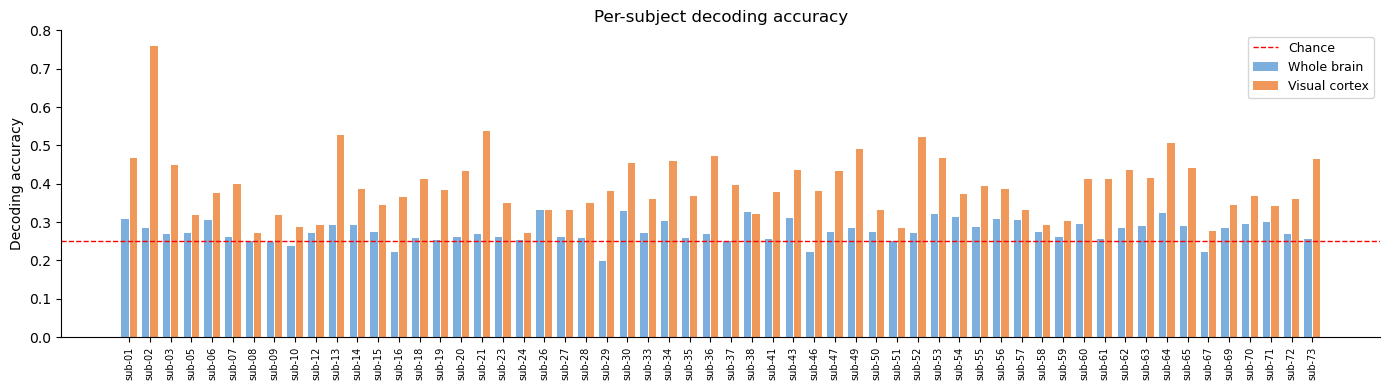

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

x = np.arange(len(df))
ax.bar(x - 0.2, df["wholebrain"], width=0.35, label="Whole brain", color="#5B9BD5", alpha=0.8)
ax.bar(x + 0.2, df["visualcortex"], width=0.35, label="Visual cortex", color="#ED7D31", alpha=0.8)
ax.axhline(CHANCE, color='red', linestyle='--', linewidth=1, label='Chance')

ax.set_xticks(x)
ax.set_xticklabels([f"sub-{s}" for s in df["subject"]], rotation=90, fontsize=7)
ax.set_ylabel("Decoding accuracy")
ax.set_ylim(0, 0.8)
ax.set_title("Per-subject decoding accuracy")
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()